<a href="https://colab.research.google.com/github/Devadeth-cmyk/vehicle-damage-insurance-ai/blob/development/damage_detection_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Libraries

In [3]:
!pip install ultralytics opencv-python-headless pyyaml -q
import os, shutil, time
import yaml
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 8.4 MB/s eta 0:00:00


# Read Dataset

In [4]:
DRIVE_PROJECT_ROOT = '/content/drive/MyDrive/AI ML/Projects/CARDD_YOLO'
LOCAL_PROJECT_ROOT = '/content/CARDD_YOLO'

assert os.path.isdir(DRIVE_PROJECT_ROOT), f'Drive dataset not found at {DRIVE_PROJECT_ROOT} — update the path'

if os.path.isdir(LOCAL_PROJECT_ROOT):
    print('Local copy already exists at', LOCAL_PROJECT_ROOT, '— skipping copy. Delete it first if you want to re-copy.')
else:
    print('Copying dataset from Drive to local disk — this happens once per session...')
    start = time.time()
    shutil.copytree(DRIVE_PROJECT_ROOT, LOCAL_PROJECT_ROOT)
    print(f'Copy complete in {time.time() - start:.1f} seconds')

PROJECT_ROOT = LOCAL_PROJECT_ROOT
yaml_path = f'{PROJECT_ROOT}/data.yaml'

Copying dataset from Drive to local disk — this happens once per session...
Copy complete in 316.3 seconds


##Validate the Local Dataset

In [5]:
print('YOLO dataset root (local):', PROJECT_ROOT)
print('data.yaml exists:', os.path.exists(yaml_path))

for split in ['train', 'val', 'test']:
    image_dir = f'{PROJECT_ROOT}/images/{split}'
    label_dir = f'{PROJECT_ROOT}/labels/{split}'
    if os.path.isdir(image_dir) and os.path.isdir(label_dir):
        print(f'{split}: images={len(os.listdir(image_dir))}, labels={len(os.listdir(label_dir))}')
    else:
        print(f'{split}: NOT FOUND (image_dir exists={os.path.isdir(image_dir)}, label_dir exists={os.path.isdir(label_dir)})')

YOLO dataset root (local): /content/CARDD_YOLO
data.yaml exists: True
train: images=2816, labels=2816
val: images=810, labels=810
test: images=374, labels=374


In [6]:
assert os.path.exists(yaml_path), 'data.yaml not found in local copy'

with open(yaml_path, 'r') as f:
    data_yaml = yaml.safe_load(f)

# data.yaml paths must point to LOCAL paths now, not Drive — rewrite and save a local version
data_yaml['train'] = f'{PROJECT_ROOT}/images/train'
data_yaml['val'] = f'{PROJECT_ROOT}/images/val'
if os.path.isdir(f'{PROJECT_ROOT}/images/test'):
    data_yaml['test'] = f'{PROJECT_ROOT}/images/test'

with open(yaml_path, 'w') as f:
    yaml.safe_dump(data_yaml, f)

print('data.yaml contents (paths rewritten to local disk):')
print(data_yaml)

assert os.path.isdir(f'{PROJECT_ROOT}/images/train'), 'Training images folder not found'
assert os.path.isdir(f'{PROJECT_ROOT}/labels/train'), 'Training labels folder not found'
print('\nLocal dataset is ready for training.')

data.yaml contents (paths rewritten to local disk):
{'path': '/content/drive/MyDrive/AI ML/Projects/CARDD_YOLO', 'train': '/content/CARDD_YOLO/images/train', 'val': '/content/CARDD_YOLO/images/val', 'test': '/content/CARDD_YOLO/images/test', 'names': ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']}

Local dataset is ready for training.


##Detecting Label Format

In [7]:
label_dir = f'{PROJECT_ROOT}/labels/train'
label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
sample_files = random.sample(label_files, min(20, len(label_files)))

line_lengths = []
for fname in sample_files:
    with open(os.path.join(label_dir, fname)) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                line_lengths.append(len(parts))

if not line_lengths:
    raise ValueError('No label content found — check that label .txt files are not empty')

max_len = max(line_lengths)
is_segmentation = max_len > 5

print(f'Sampled {len(sample_files)} label files, {len(line_lengths)} annotation lines')
print(f'Max fields per line: {max_len}')
print(f'Detected format: {"SEGMENTATION (polygon masks)" if is_segmentation else "DETECTION (bounding boxes)"}')

MODEL_NAME = 'yolov8n-seg.pt' if is_segmentation else 'yolov8n.pt'
print(f'\nModel to use: {MODEL_NAME}')

Sampled 20 label files, 34 annotation lines
Max fields per line: 5
Detected format: DETECTION (bounding boxes)

Model to use: yolov8n.pt


##Image Checking

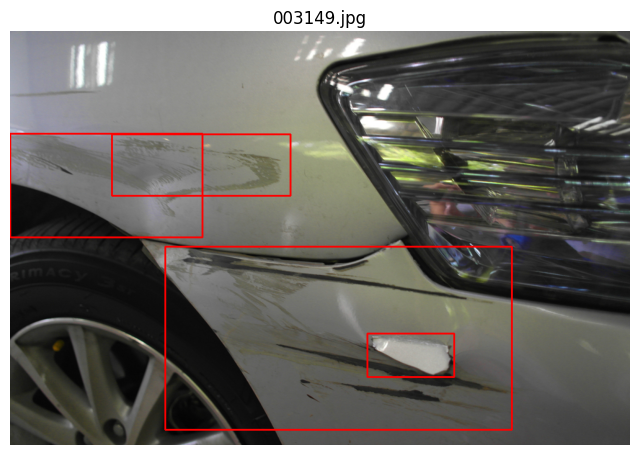

In [8]:
img_dir = f'{PROJECT_ROOT}/images/train'
img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
sample_img_name = random.choice(img_files)
sample_label_name = os.path.splitext(sample_img_name)[0] + '.txt'

img = cv2.imread(os.path.join(img_dir, sample_img_name))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

label_path = os.path.join(label_dir, sample_label_name)
if os.path.exists(label_path):
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls = int(parts[0])
            coords = list(map(float, parts[1:]))
            if is_segmentation:
                pts = [(int(coords[i]*w), int(coords[i+1]*h)) for i in range(0, len(coords), 2)]
                for i in range(len(pts)):
                    cv2.line(img, pts[i], pts[(i+1) % len(pts)], (255, 0, 0), 2)
            else:
                xc, yc, bw, bh = coords
                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title(sample_img_name)
plt.axis('off')
plt.show()

#Model Training

In [9]:
model = YOLO(MODEL_NAME)

results = model.train(
    data = yaml_path,
    epochs = 30,
    imgsz = 640,
    batch = 16,
    device = 0,
    project = '/content/runs',
    name = 'car_damage_yolov8',
    patience = 10
)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CARDD_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0,

In [10]:
## Resume training if a session disconnects mid-run
# last_ckpt = '/content/runs/car_damage_yolov8/weights/last.pt'
# model = YOLO(last_ckpt)
# results = model.train(resume=True)

#Evaluation

In [11]:
best_model_path_local = '/content/runs/car_damage_yolov8/weights/best.pt'
trained_model = YOLO(best_model_path_local)

metrics = trained_model.val()

print('Box mAP50-95:', metrics.box.map)
print('Box mAP50:', metrics.box.map50)
if hasattr(metrics, 'seg') and metrics.seg is not None:
    print('Seg mAP50-95:', metrics.seg.map)
    print('Seg mAP50:', metrics.seg.map50)

print('\nPer-class results:')
names_iter = data_yaml.get('names', {}).items() if isinstance(data_yaml.get('names'), dict) else enumerate(data_yaml.get('names', []))
for i, name in names_iter:
    try:
        print(f'  {name}: mAP50-95 = {metrics.box.maps[i]:.3f}')
    except Exception:
        pass

Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4457.1±896.3 MB/s, size: 715.1 KB)
val: Scanning /content/CARDD_YOLO/labels/val.cache... 810 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 810/810 261.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 3.4it/s 14.9s
                   all        810       1744      0.749      0.666      0.709      0.554
                  dent        352        501      0.673      0.491      0.554      0.312
               scratch        431        728      0.633      0.484      0.541        0.3
                 crack        122        177       0.53      0.305      0.347      0.172
         glass shatter        134        135      0.968      0.978      0.992      0.929
           lamp broken        139        141

In [12]:
# Copy final weights and best model to Google drive
drive_runs_dest = f'{DRIVE_PROJECT_ROOT}/runs/car_damage_yolov8'

os.makedirs(os.path.dirname(drive_runs_dest), exist_ok=True)
if os.path.isdir(drive_runs_dest):
    shutil.rmtree(drive_runs_dest)

print('Copying trained model + logs to Drive (one-time write)...')
shutil.copytree('/content/runs/car_damage_yolov8', drive_runs_dest)

best_model_path = f'{drive_runs_dest}/weights/best.pt'
print('Saved to Drive at:', best_model_path)

Copying trained model + logs to Drive (one-time write)...
Saved to Drive at: /content/drive/MyDrive/AI ML/Projects/CARDD_YOLO/runs/car_damage_yolov8/weights/best.pt


#Testing

Running inference on: /content/CARDD_YOLO/images/test/001963.jpg

image 1/1 /content/CARDD_YOLO/images/test/001963.jpg: 416x640 1 dent, 2 scratchs, 55.3ms
Speed: 1.8ms preprocess, 55.3ms inference, 1.3ms postprocess per image at shape (1, 3, 416, 640)


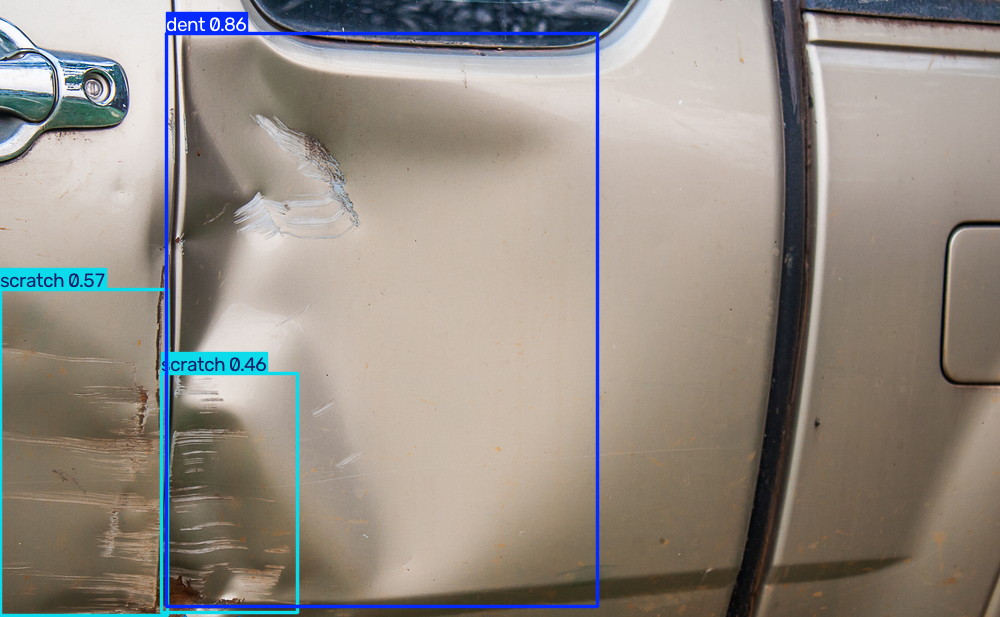

In [29]:
# Testing on sample images
test_img_dir = f'{PROJECT_ROOT}/images/test'
if os.path.isdir(test_img_dir) and len(os.listdir(test_img_dir)) > 0:
    test_img_name = random.choice(os.listdir(test_img_dir))
    test_img_path = os.path.join(test_img_dir, test_img_name)
else:
    val_img_dir = f'{PROJECT_ROOT}/images/val'
    test_img_name = random.choice(os.listdir(val_img_dir))
    test_img_path = os.path.join(val_img_dir, test_img_name)

print('Running inference on:', test_img_path)
results = trained_model(test_img_path)
results[0].show()

In [14]:
# Final Model path
print('Trained model permanently saved at (Drive):')
print(best_model_path)

Trained model permanently saved at (Drive):
/content/drive/MyDrive/AI ML/Projects/CARDD_YOLO/runs/car_damage_yolov8/weights/best.pt

Use this exact path in later notebooks (severity scoring, end-to-end pipeline):
model = YOLO('/content/drive/MyDrive/AI ML/Projects/CARDD_YOLO/runs/car_damage_yolov8/weights/best.pt')
